For the first problem we are asked to consider a function which has the z2 symmetry. f(x)=f(-x)
I skimmed gemoetric deep learning and consulted chatgpt.
h(x)=(f(x)-f(-x))/2

In [67]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

N=80

np.random.seed(0)
# make training data
x_train= np.random.uniform(-2,5, size=(N,1)) #its interesting to see if 
#make a dumb even function and add noise
def f(x):
    return(-.4*x**2+np.sin(x)**2)
y_train= f(x_train)

Ntest=100
x_test=np.linspace(-4,4, Ntest)
y_test=f(x_test)



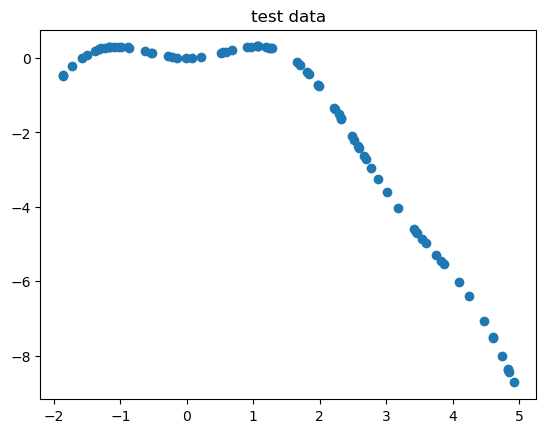

In [68]:
plt.title('test data')
plt.scatter(x_train,y_train)

/Users/Krishna/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Krishna/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


74.82307126234566


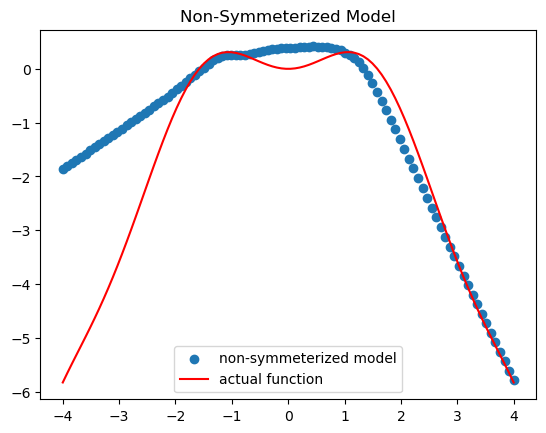

In [80]:
#now going to make a multi layer perceptron
layersize=32
mlp_model=MLPRegressor(hidden_layer_sizes=(layersize,layersize), 
                  activation='relu', 
                  solver='adam', 
                  random_state=13, 
                  alpha=3e-4, 
                  max_iter=200)

mlp_model.fit(x_train, y_train)
y_pred = mlp_model.predict(x_test.reshape(-1,1))

plt.title('Non-Symmeterized Model')
plt.scatter(x_test,y_pred, label='non-symmeterized model')
plt.plot(x_test, y_test, color='r', label='actual function')
plt.legend()
print(np.sum(np.abs(y_test-y_pred)))

I asked chatgpt to help symmeterize my model and it suggested just taking the same unsymterized model i just trained and symmeterizing it. BUt that is not what i want. I want to symmeterize, then calculate the loss, then update the weights. It told me that sci kit learn mlp regressor cant do this but i can use PyTorch. Last PS i didnt use PyTorch, so lets get started using py torch and the example code it gave me

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim

class EvenMLP(nn.Module):
    def __init__(self, hidden=layersize):
        super().__init__()
        self.g = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden,hidden),
            nn.Tanh(),
            nn.Linear(hidden,1)
        ) #ok i stole that part from chatgpt but it looks like we are defining a a linear map from 1 d to 16 d, another 16 d to 16 d and then 16d back to 1d, with a tanh activation function

    def forward(self, x): 
        return 0.5 * ( self.g(x)+ self.g(-x) ) #this looks like where we implement the loss function on the symmeterized part

x_train_torch = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

x_test_torch=torch.tensor(x_test,  dtype=torch.float32).view(-1, 1)
y_test_torch=torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

model= EvenMLP()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn= nn.MSELoss()

for epoch in range (2000):
    optimizer.zero_grad() 
    y_pred=model(x_train_torch)
    loss= loss_fn(y_pred, y_train_torch)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred_symm=model(x_test_torch)
    test_loss = loss_fn(y_pred_symm,y_test_torch)


tensor(0.0006)


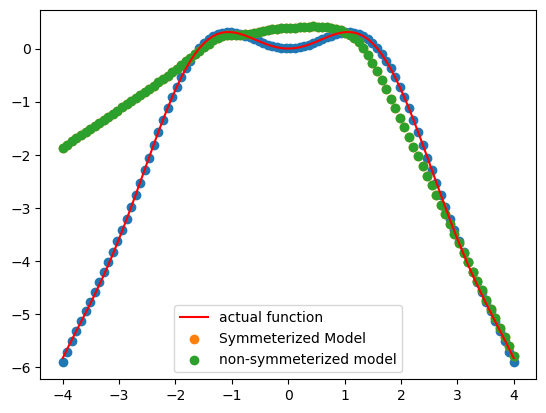

In [81]:
plt.scatter(x_test,y_pred_symm)
plt.plot(x_test, y_test, color='r', label='actual function')
print(test_loss)
plt.scatter(x_test,y_pred, label='Symmeterized Model')
plt.scatter(x_test,y_pred, label='non-symmeterized model')

plt.legend()